# 1D Burgers Equation Sampling method Evaluation

This notebook demonstrates solving 1D Burgers Equation (spatial xy version) using PINNs.

In [1]:
import deepflow as df
print("Deepflow is runned on:", df.device) # to change to cpu use df.device = 'cpu'
df.manual_seed(69) # for reproducibility

Deepflow is runned on: cuda


# 0. Evaluation Metrics

In [2]:
sampling_methods = ['r3', 'random', 'randomr']

## 1. Define Geometry and Physics
Set up the computational domain

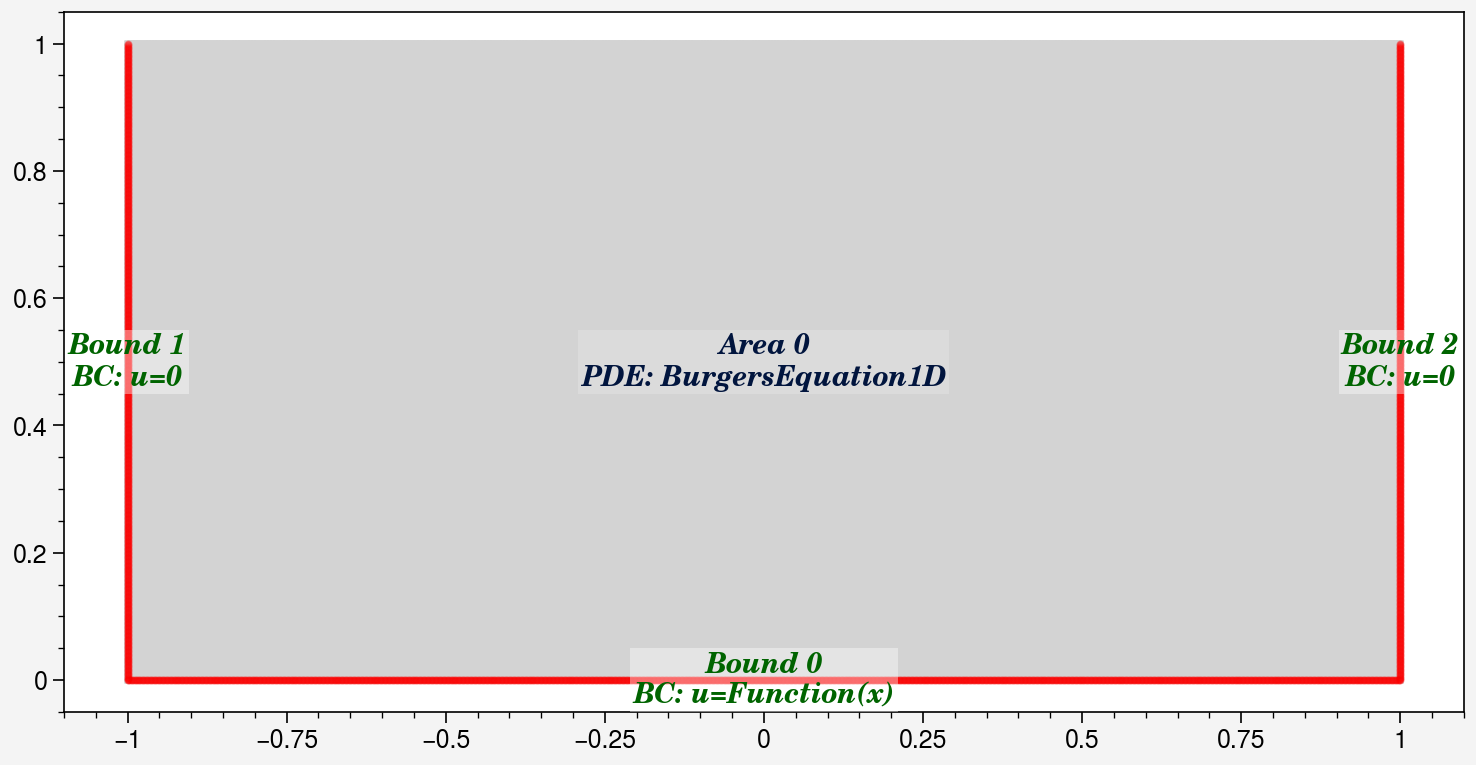

In [3]:
# Define Geometry and Computational Domain
area = df.geometry.rectangle([-1, 1], [0, 1])
line_ic = df.geometry.line_horizontal(y=0, range_x=[-1,1])
line_bc1 = df.geometry.line_vertical(x=-1, range_y=[0,1])
line_bc2 = df.geometry.line_vertical(x=1, range_y=[0,1])
domain = df.domain(area.area_list, line_ic, line_bc1, line_bc2)

# Define PDE
from torch import sin, pi
domain.area_list[0].define_pde(df.pde.BurgersEquation1D(nu=0.01/pi))
domain.bound_list[0].define_bc({'u':['x', lambda x: -sin(pi * x)]})
domain.bound_list[1].define_bc({'u': 0})
domain.bound_list[2].define_bc({'u': 0})
domain.show_setup()

### 3. Train the Model

Define the resampling scheme during training. [R3](https://arxiv.org/abs/2207.02338) scheme is recommended.

Epoch: 1, total_loss: 0.65494, bc_loss: 0.65192, pde_loss: 0.00302
Epoch: 200, total_loss: 0.28447, bc_loss: 0.20204, pde_loss: 0.08243
Epoch: 400, total_loss: 0.20091, bc_loss: 0.13831, pde_loss: 0.06260
number of bound : ['0: 1000', '1: 500', '2: 500']
number of area : ['0: 4000']


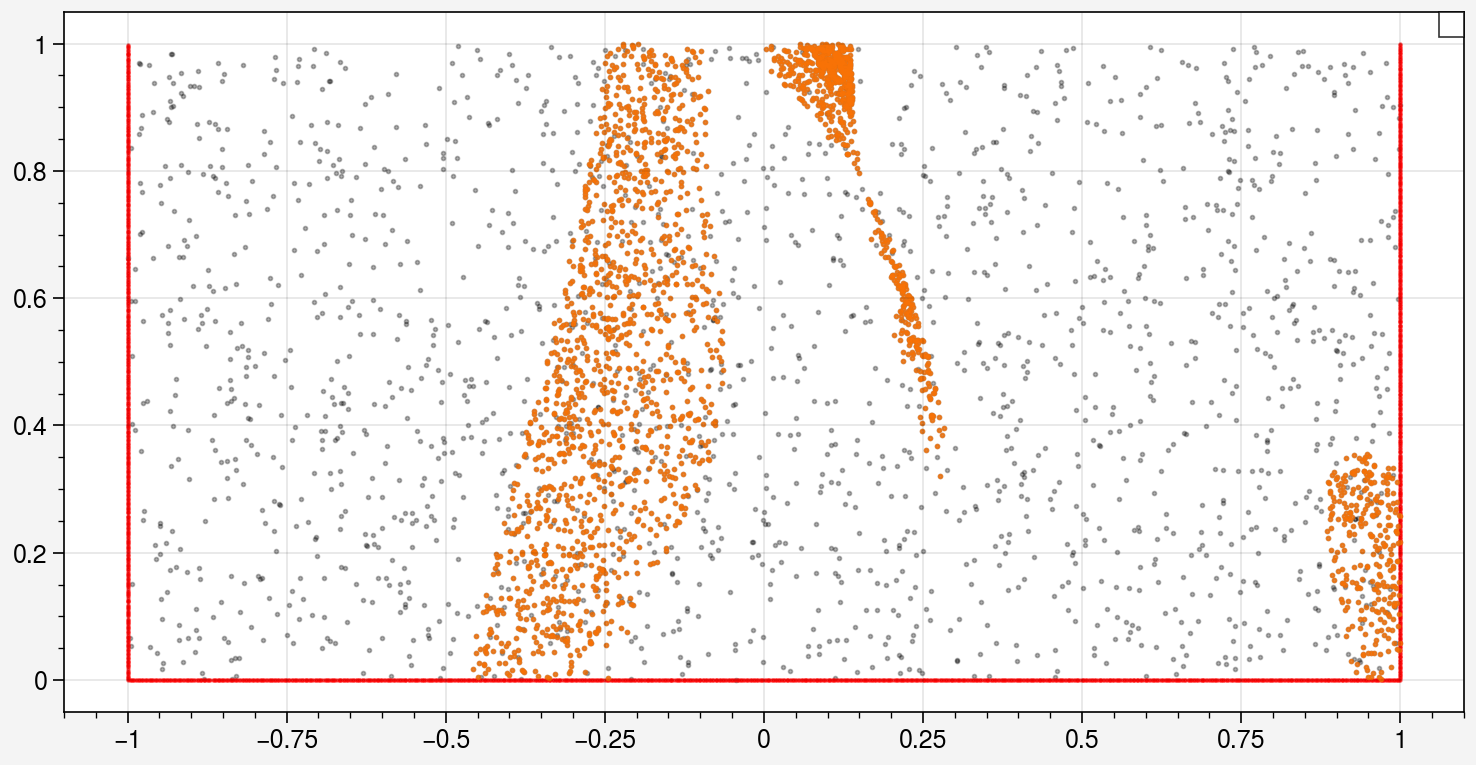

Epoch: 600, total_loss: 0.17640, bc_loss: 0.10466, pde_loss: 0.07173
Epoch: 800, total_loss: 0.15428, bc_loss: 0.12898, pde_loss: 0.02531
Epoch: 1000, total_loss: 0.16500, bc_loss: 0.10896, pde_loss: 0.05604
number of bound : ['0: 1000', '1: 500', '2: 500']
number of area : ['0: 4000']


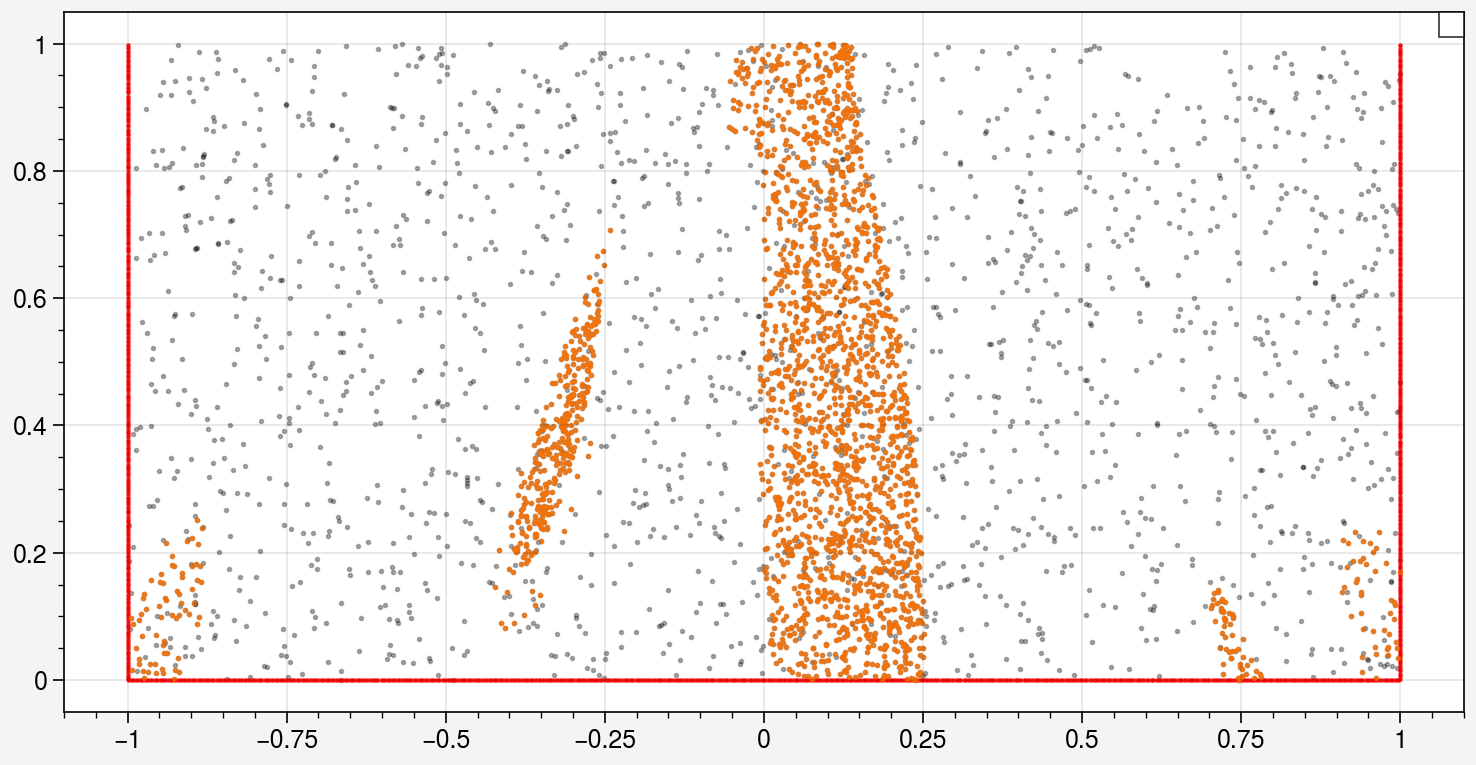

Epoch: 1200, total_loss: 0.16344, bc_loss: 0.10076, pde_loss: 0.06268
Epoch: 1400, total_loss: 0.13840, bc_loss: 0.10862, pde_loss: 0.02978
number of bound : ['0: 1000', '1: 500', '2: 500']
number of area : ['0: 4000']


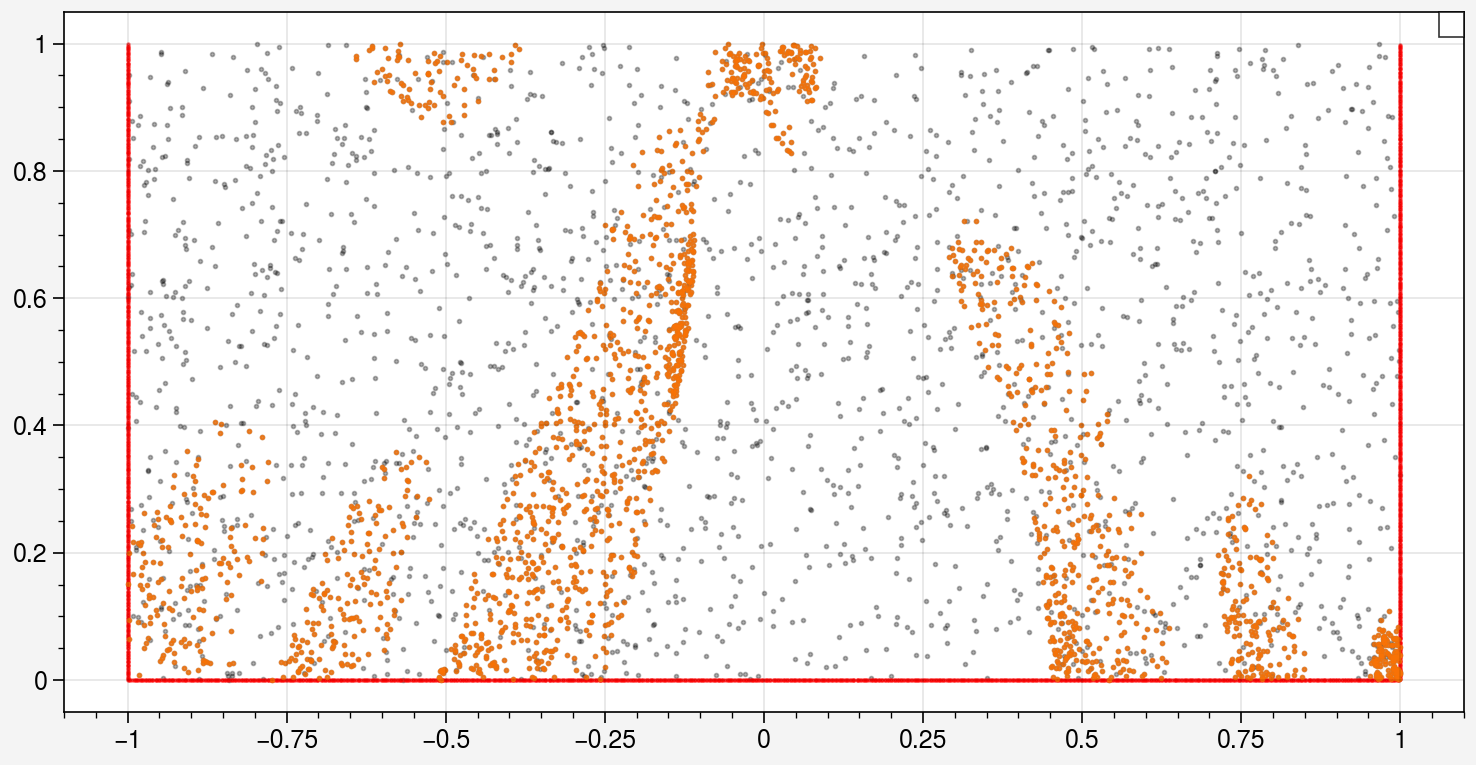

Epoch: 1600, total_loss: 0.13007, bc_loss: 0.09393, pde_loss: 0.03614
Epoch: 1800, total_loss: 0.11646, bc_loss: 0.09852, pde_loss: 0.01794
Epoch: 2000, total_loss: 0.11388, bc_loss: 0.08063, pde_loss: 0.03326
number of bound : ['0: 1000', '1: 500', '2: 500']
number of area : ['0: 4000']


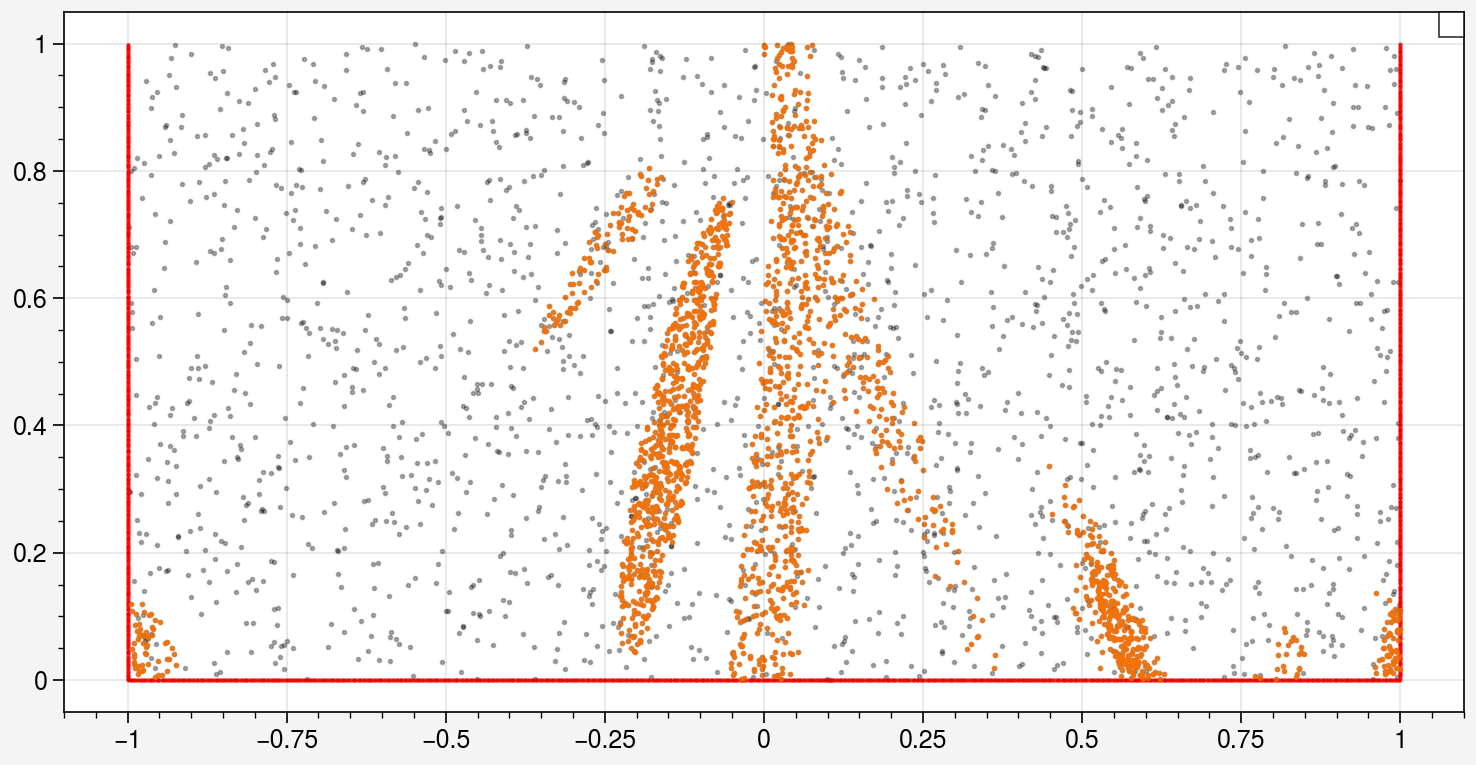

Epoch: 2200, total_loss: 0.10504, bc_loss: 0.09141, pde_loss: 0.01363
Epoch: 2400, total_loss: 0.07838, bc_loss: 0.05157, pde_loss: 0.02681
number of bound : ['0: 1000', '1: 500', '2: 500']
number of area : ['0: 4000']


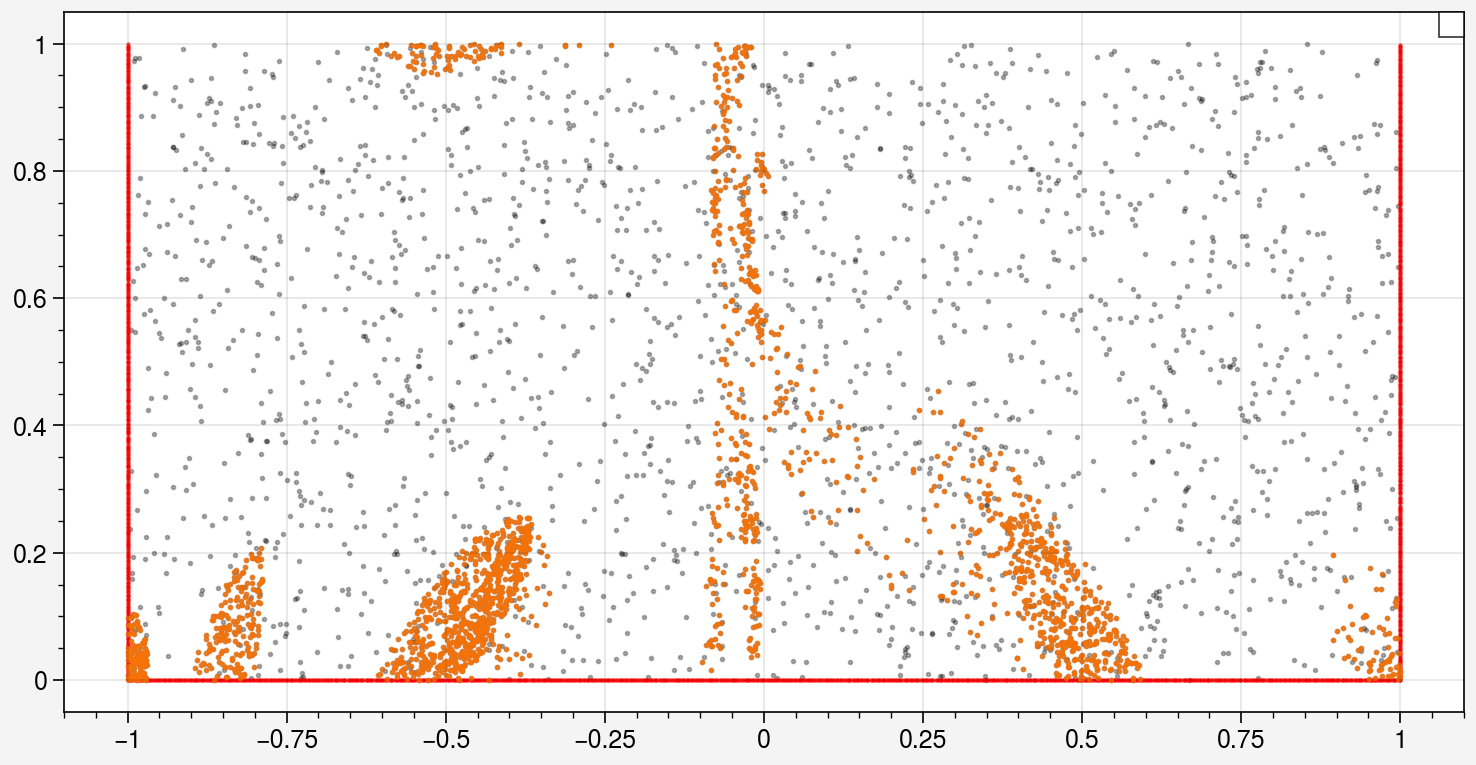

Epoch: 2600, total_loss: 0.07080, bc_loss: 0.05148, pde_loss: 0.01932
Epoch: 2800, total_loss: 0.05497, bc_loss: 0.03707, pde_loss: 0.01789
Epoch: 3000, total_loss: 0.04946, bc_loss: 0.02716, pde_loss: 0.02230
number of bound : ['0: 1000', '1: 500', '2: 500']
number of area : ['0: 4000']


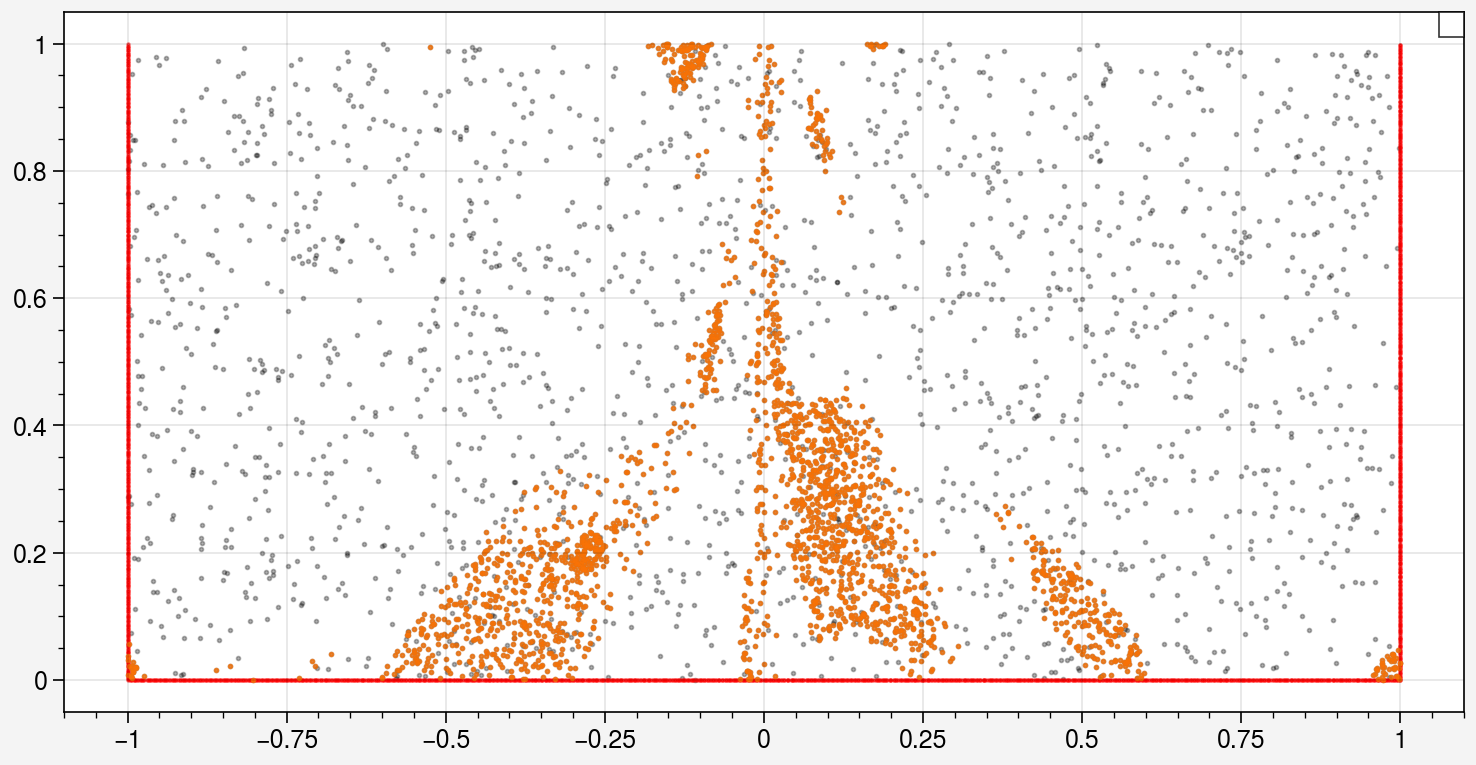

Epoch: 3200, total_loss: 0.05116, bc_loss: 0.02751, pde_loss: 0.02365
Epoch: 3400, total_loss: 0.03138, bc_loss: 0.02110, pde_loss: 0.01028
number of bound : ['0: 1000', '1: 500', '2: 500']
number of area : ['0: 4000']


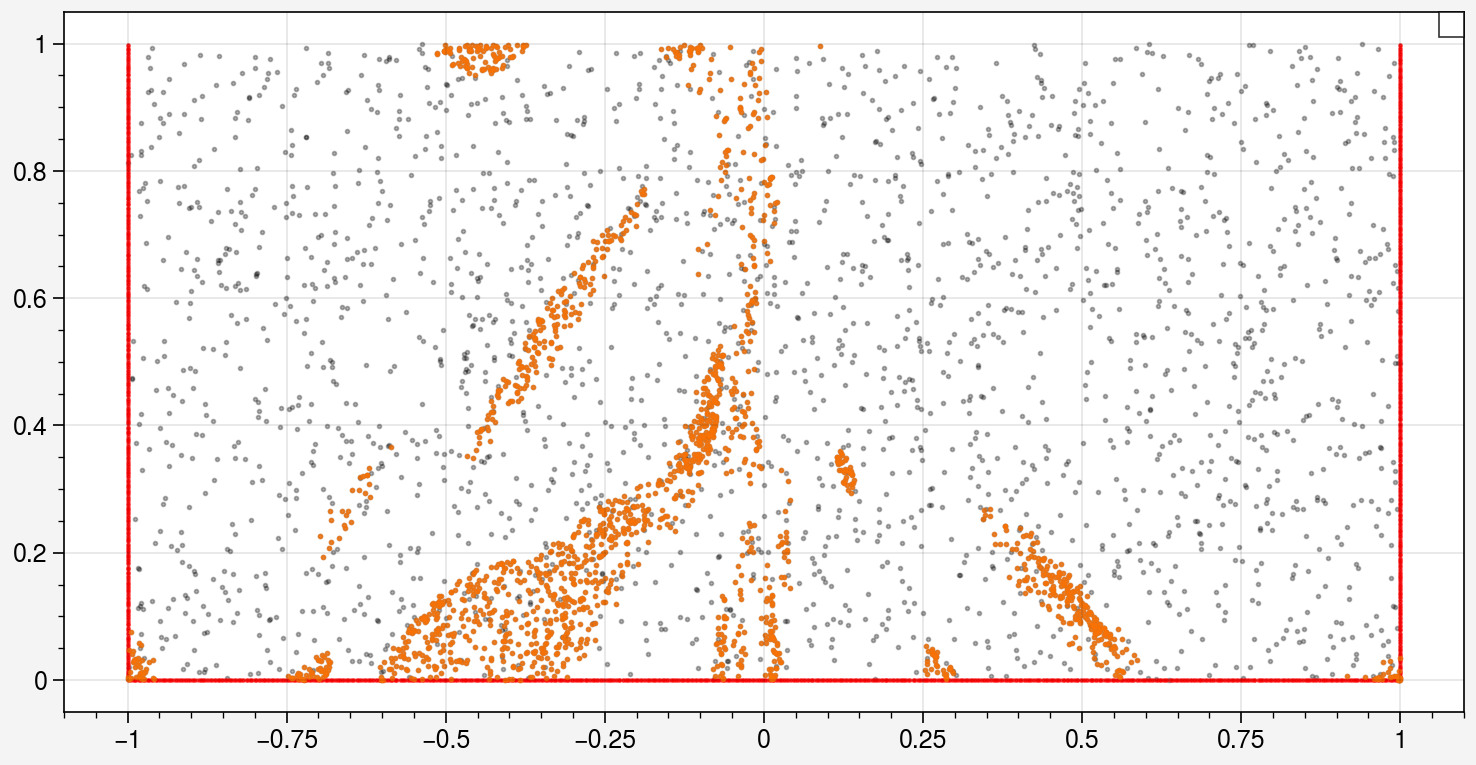

Epoch: 3600, total_loss: 0.02530, bc_loss: 0.01715, pde_loss: 0.00814
Epoch: 3800, total_loss: 0.03159, bc_loss: 0.01701, pde_loss: 0.01458
Epoch: 4000, total_loss: 0.02373, bc_loss: 0.01156, pde_loss: 0.01217
number of bound : ['0: 1000', '1: 500', '2: 500']
number of area : ['0: 4000']


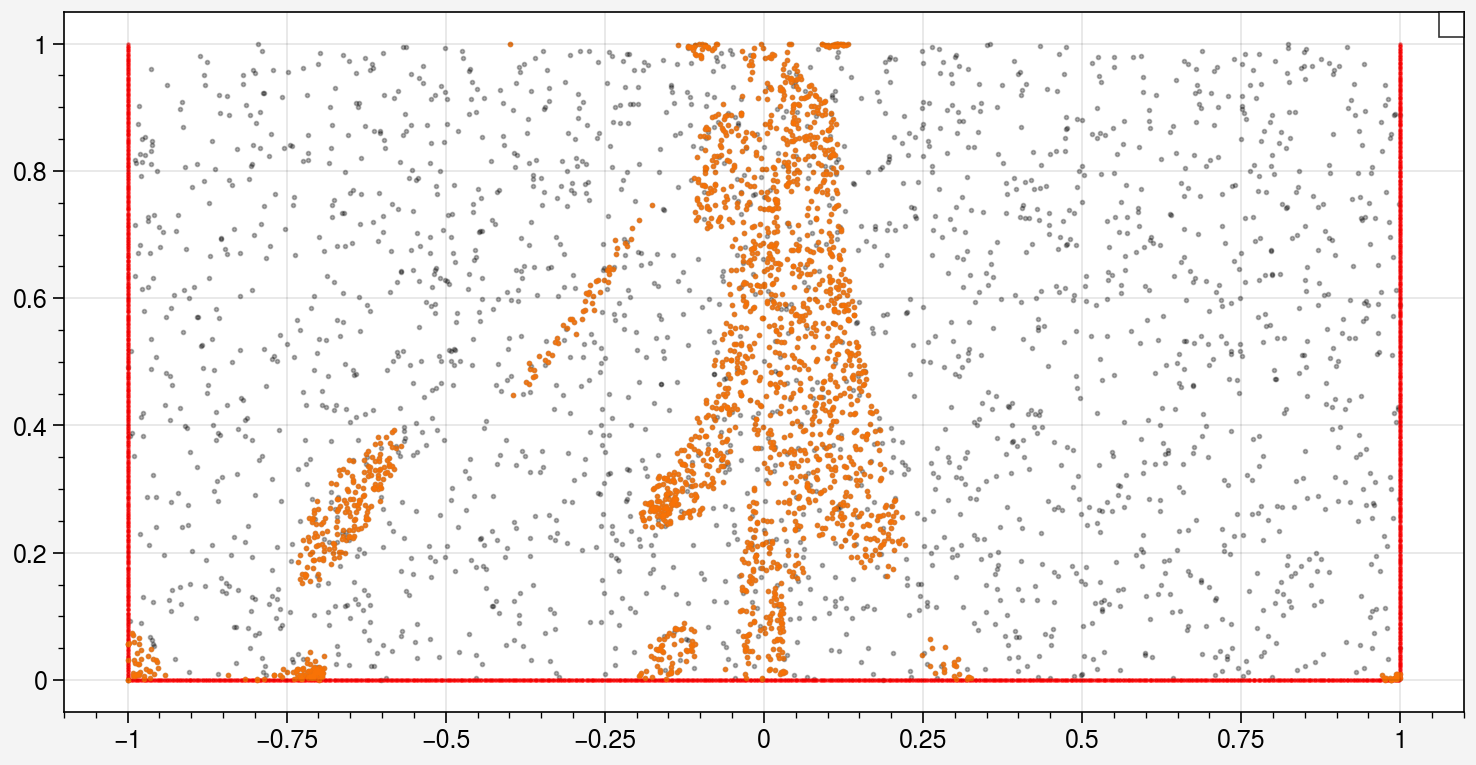

Epoch: 4200, total_loss: 0.01934, bc_loss: 0.01090, pde_loss: 0.00844
Epoch: 4400, total_loss: 0.01754, bc_loss: 0.01032, pde_loss: 0.00722
number of bound : ['0: 1000', '1: 500', '2: 500']
number of area : ['0: 4000']


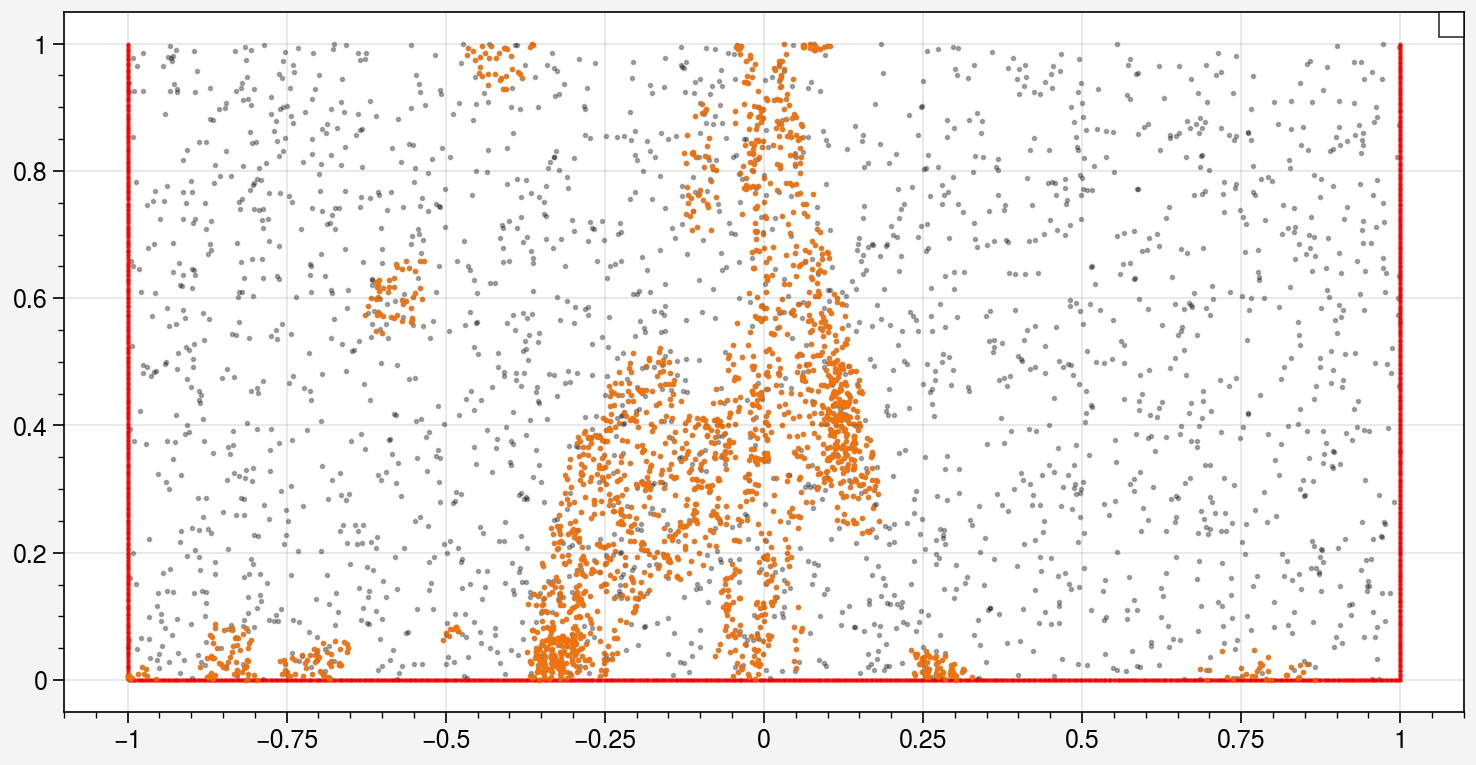

Epoch: 4600, total_loss: 0.08389, bc_loss: 0.05510, pde_loss: 0.02879
Epoch: 4800, total_loss: 0.01476, bc_loss: 0.00953, pde_loss: 0.00524
Epoch: 5000, total_loss: 0.01349, bc_loss: 0.00756, pde_loss: 0.00593
number of bound : ['0: 1000', '1: 500', '2: 500']
number of area : ['0: 4000']


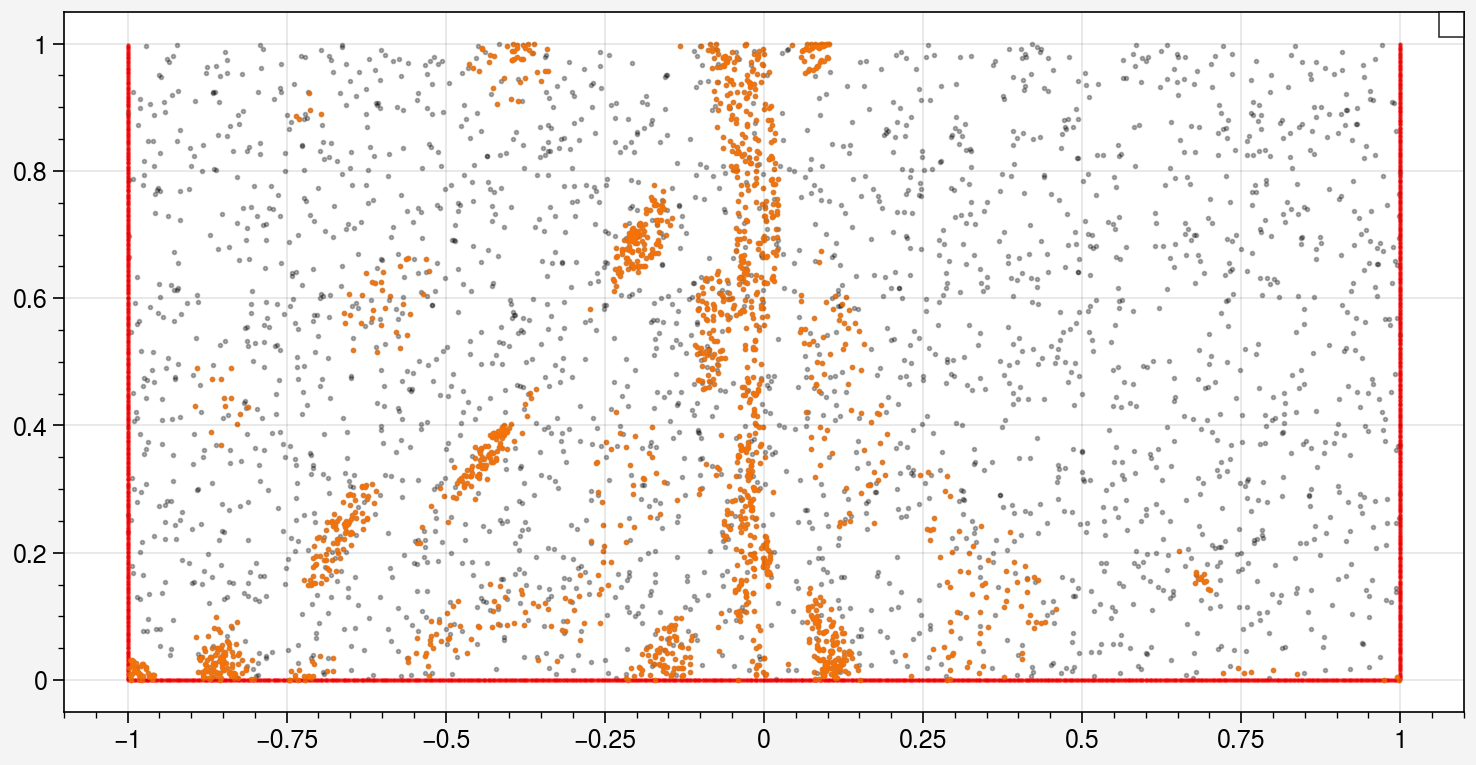

Epoch: 5000, total_loss: 0.01349, bc_loss: 0.00756, pde_loss: 0.00593
Epoch: 1, total_loss: 0.65497, bc_loss: 0.65194, pde_loss: 0.00303
Epoch: 200, total_loss: 0.13458, bc_loss: 0.08242, pde_loss: 0.05216
Epoch: 400, total_loss: 0.10469, bc_loss: 0.06146, pde_loss: 0.04322
Epoch: 600, total_loss: 0.09294, bc_loss: 0.05413, pde_loss: 0.03881
Epoch: 800, total_loss: 0.08714, bc_loss: 0.05118, pde_loss: 0.03596
Epoch: 1000, total_loss: 0.08069, bc_loss: 0.04782, pde_loss: 0.03287
Epoch: 1200, total_loss: 0.07614, bc_loss: 0.04599, pde_loss: 0.03015
Epoch: 1400, total_loss: 0.07226, bc_loss: 0.04334, pde_loss: 0.02892
Epoch: 1600, total_loss: 0.05835, bc_loss: 0.03578, pde_loss: 0.02257
Epoch: 1800, total_loss: 0.04956, bc_loss: 0.03080, pde_loss: 0.01876
Epoch: 2000, total_loss: 0.03739, bc_loss: 0.01935, pde_loss: 0.01804
Epoch: 2200, total_loss: 0.01968, bc_loss: 0.01063, pde_loss: 0.00905
Epoch: 2400, total_loss: 0.01511, bc_loss: 0.00676, pde_loss: 0.00835
Epoch: 2600, total_loss: 0.

In [ ]:
model0 = df.PINN(input_vars=['x', 'y'], output_vars=['u'], width=16, length=4)
obj_dict = {method:{} for method in sampling_methods}

def do_random(epoch, model):
    pass
obj_dict["random"]["do"] = do_random
obj_dict["random"]["lr"] = 0.004

def do_randomr(epoch, model):
    if epoch % 50 == 0 and epoch > 0:
        domain.sampling_lhs([1000, 500, 500], [4000])
obj_dict["randomr"]["do"] = do_randomr
obj_dict["randomr"]["lr"] = 0.004

def do_r3(epoch, model):
    if epoch % 50 == 0 and epoch > 0:
        domain.sampling_lhs([1000, 500, 500])
    if epoch > 0:
        domain.sampling_R3([], [4000])
    if epoch % 500 == 0:
        print(domain)
        domain.show_coordinates(display_resampling=True)
obj_dict["r3"]["do"] = do_r3
obj_dict["r3"]["lr"] = 0.004


for method in sampling_methods:
    domain.sampling_lhs([1000, 500, 500], [4000])
    obj_dict[method]["model"], _ = model0.train_adam(
        calc_loss = df.calc_loss_weighted(domain, bc_weights=1),
        learning_rate=obj_dict[method]["lr"],
        epochs=5000,
        do_between_epochs=obj_dict[method]["do"],
        print_every=200)

## 4. Visualization

In [5]:
import numpy as np
with open('../../EXPERIMENTS/burgers_reference_solution/burgers_solution.txt', 'r') as f:
    data = np.loadtxt(f)
x, y, u = data[:, 0], data[:, 1], data[:, 2]

import torch
domain_test = df.custom_data({'x':torch.tensor(x, dtype=torch.float32), 'y':torch.tensor(y, dtype=torch.float32)})

L2 error for method r3 : 0.15389265497863358
L1 error for method r3 : 0.07674425782813697
L2 error for method random : 0.2654448804606095
L1 error for method random : 0.09190945607564038
L2 error for method randomr : 0.27789953615153534
L1 error for method randomr : 0.06595647109225922


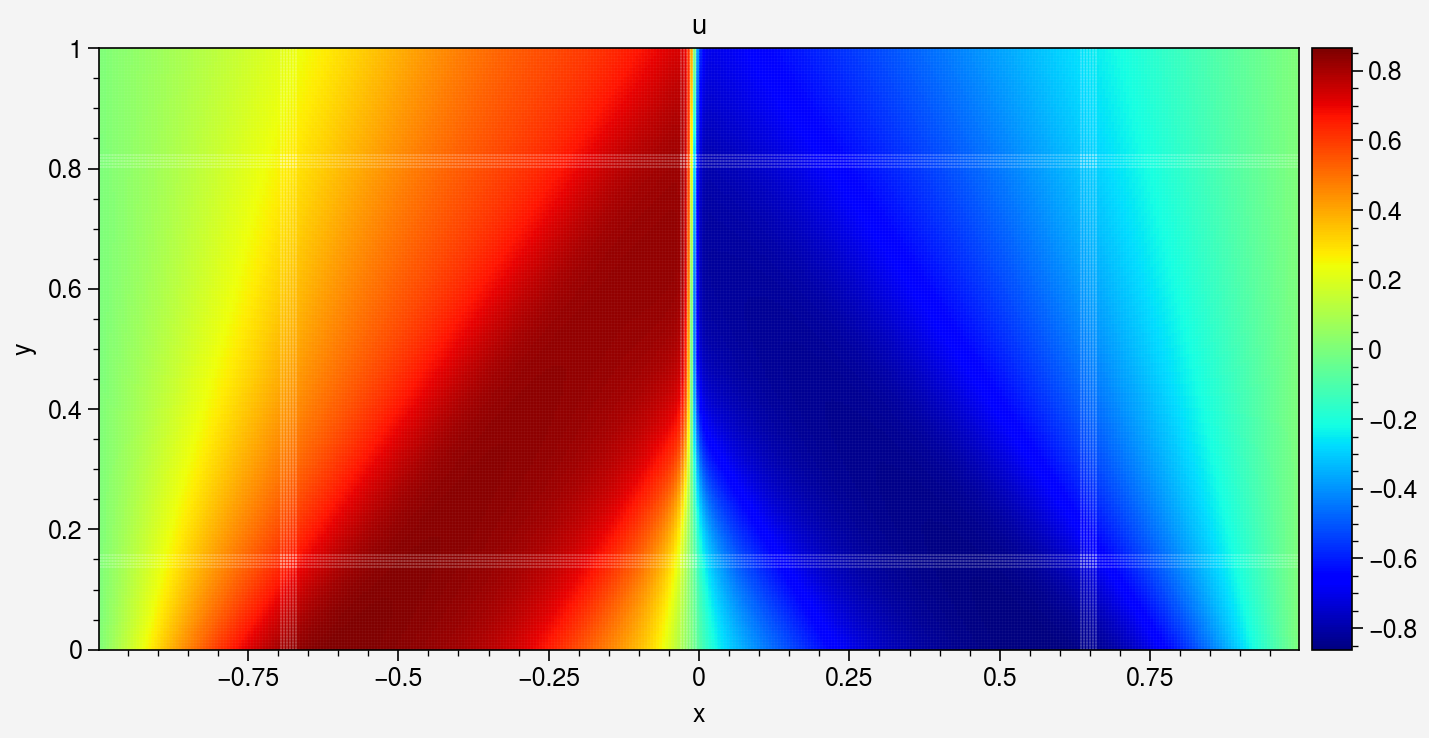

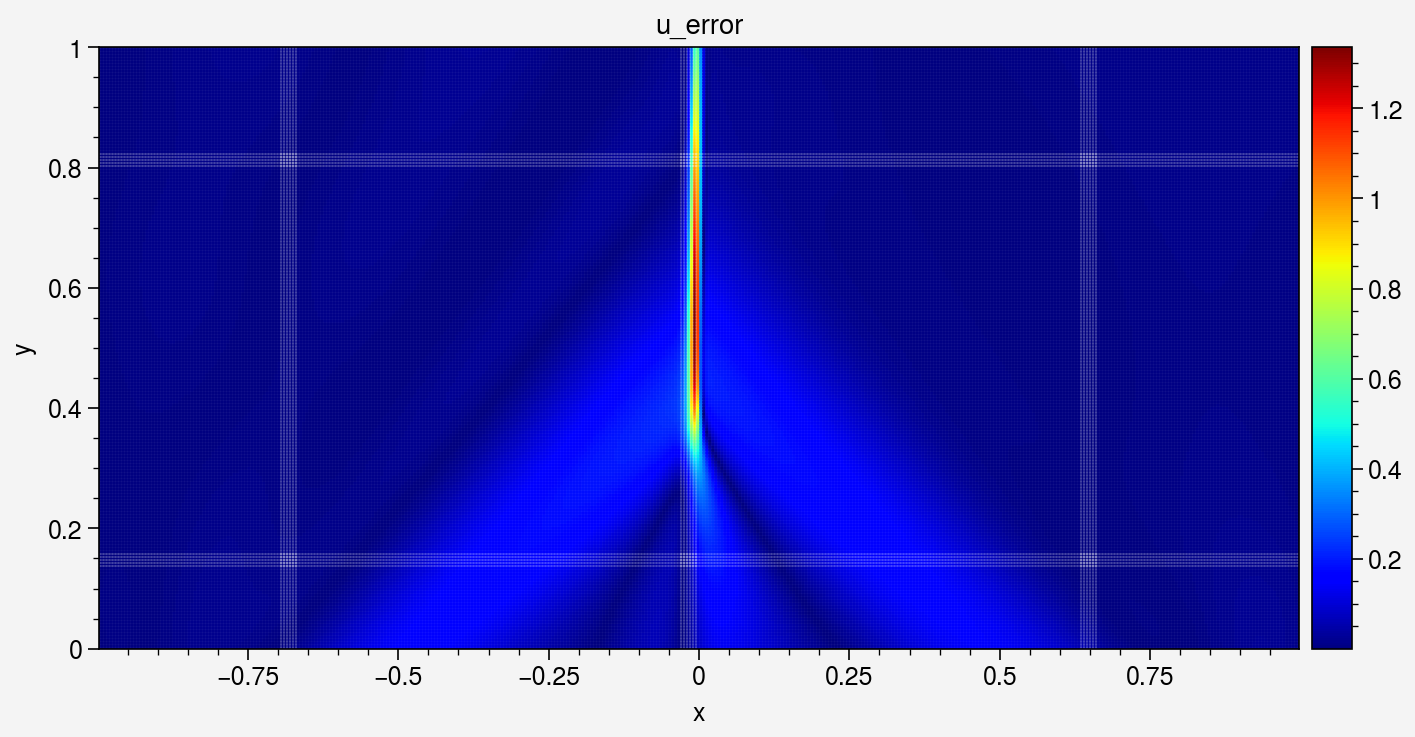

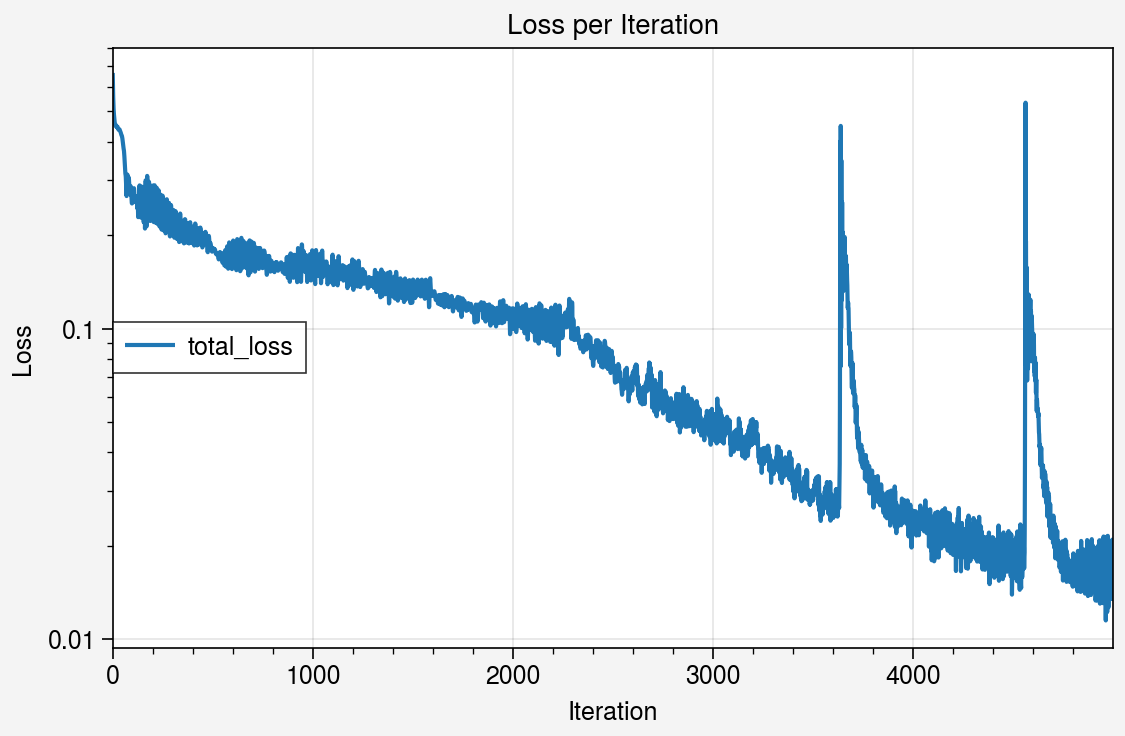

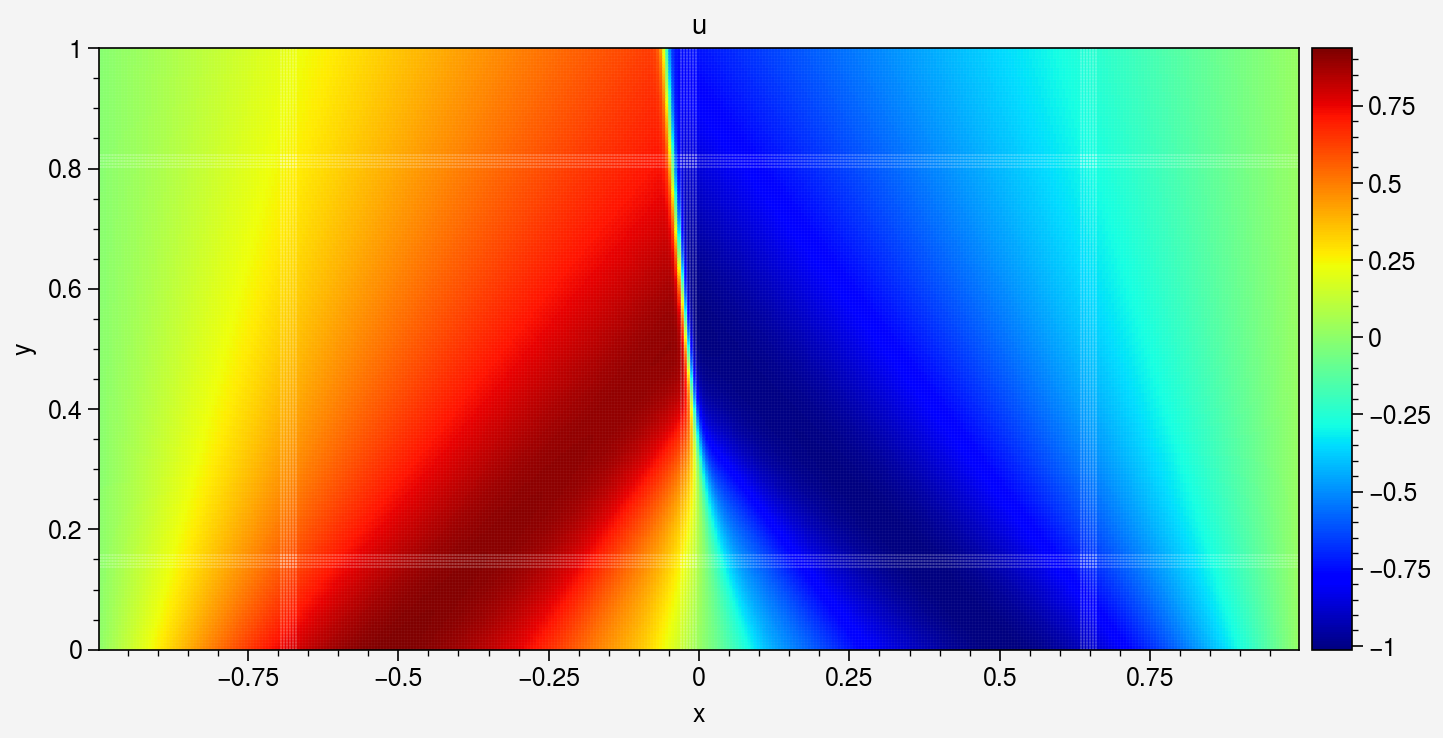

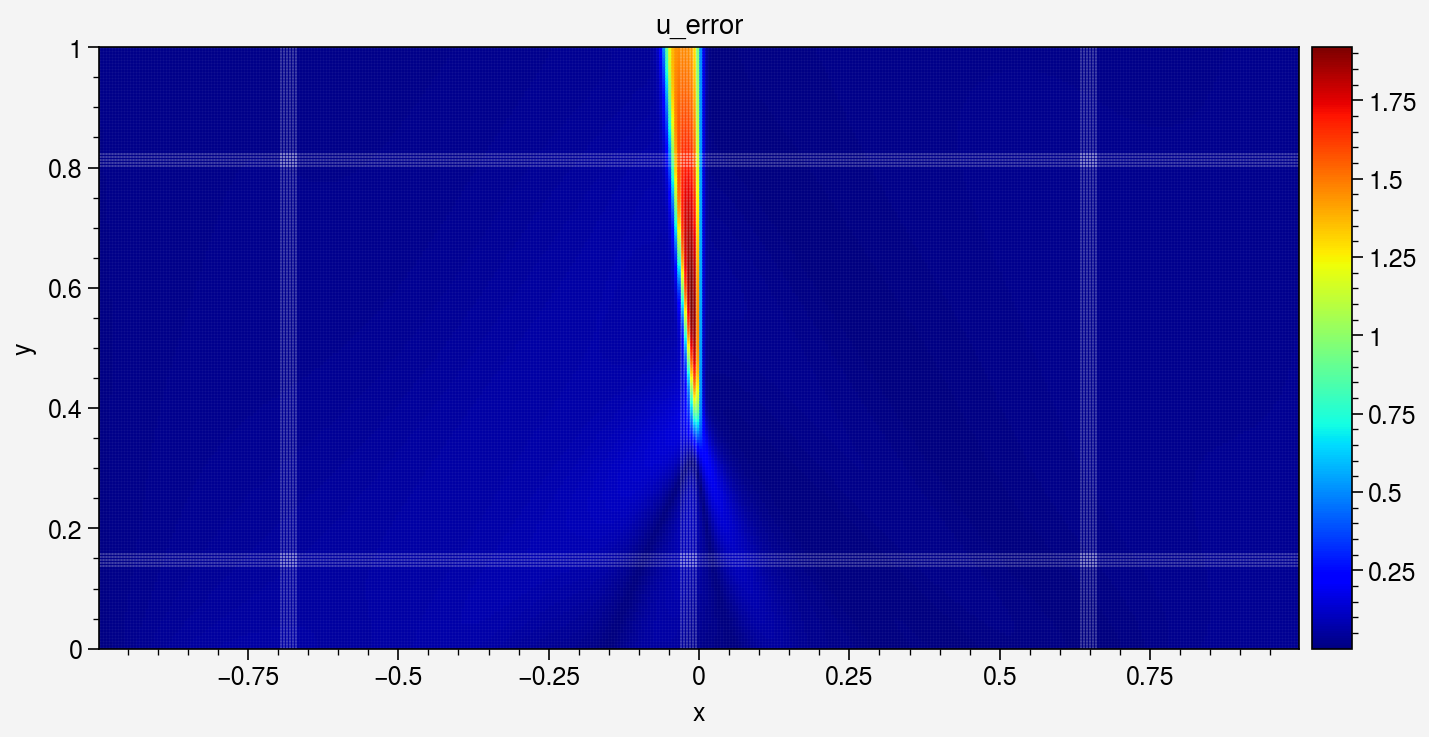

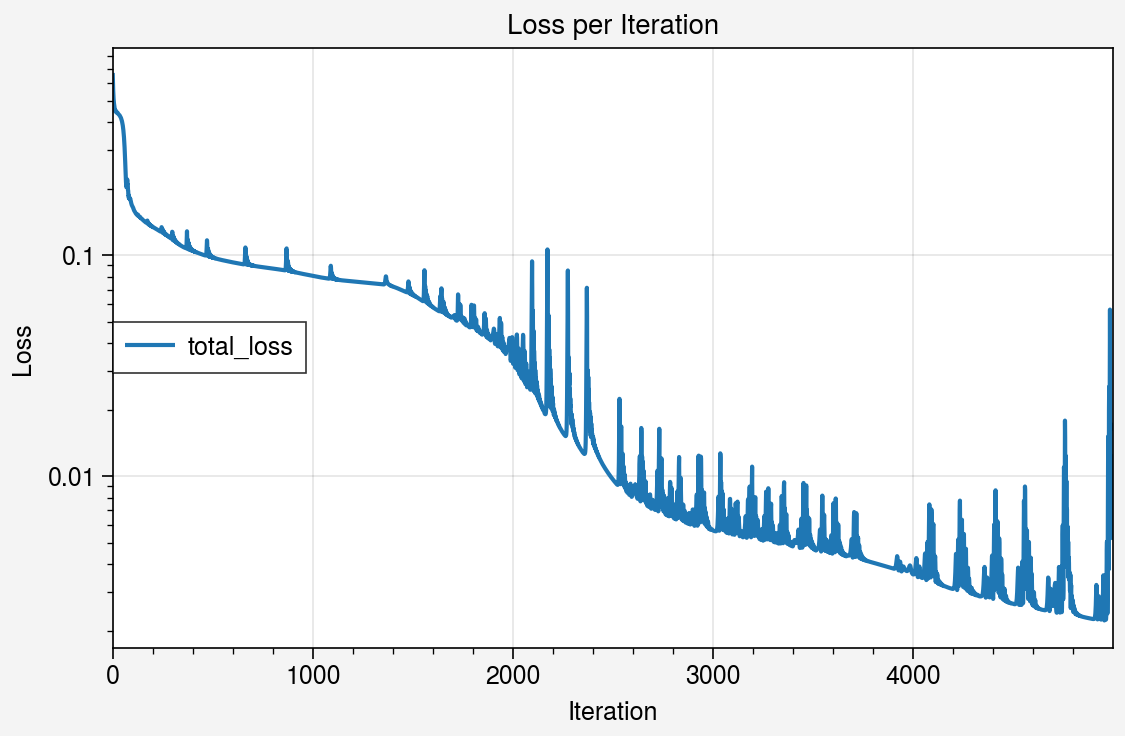

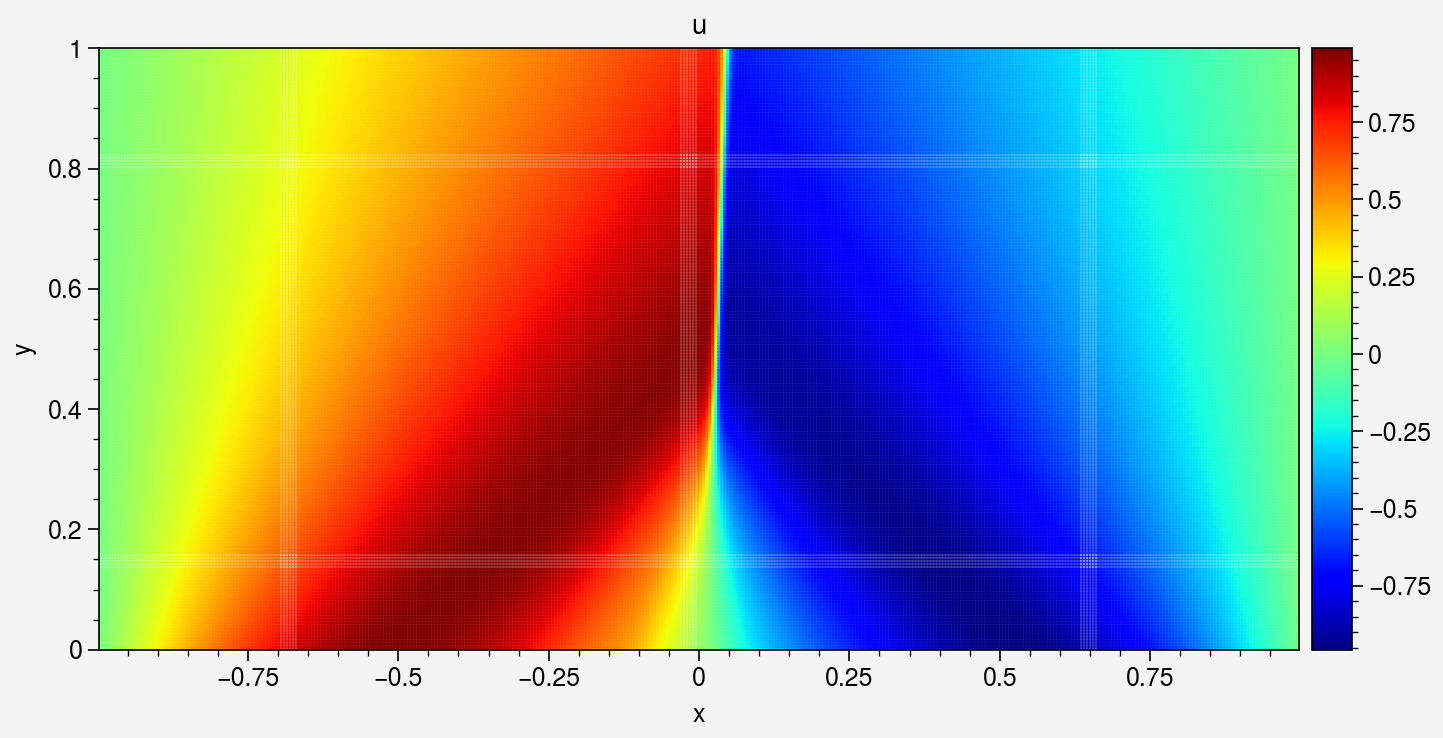

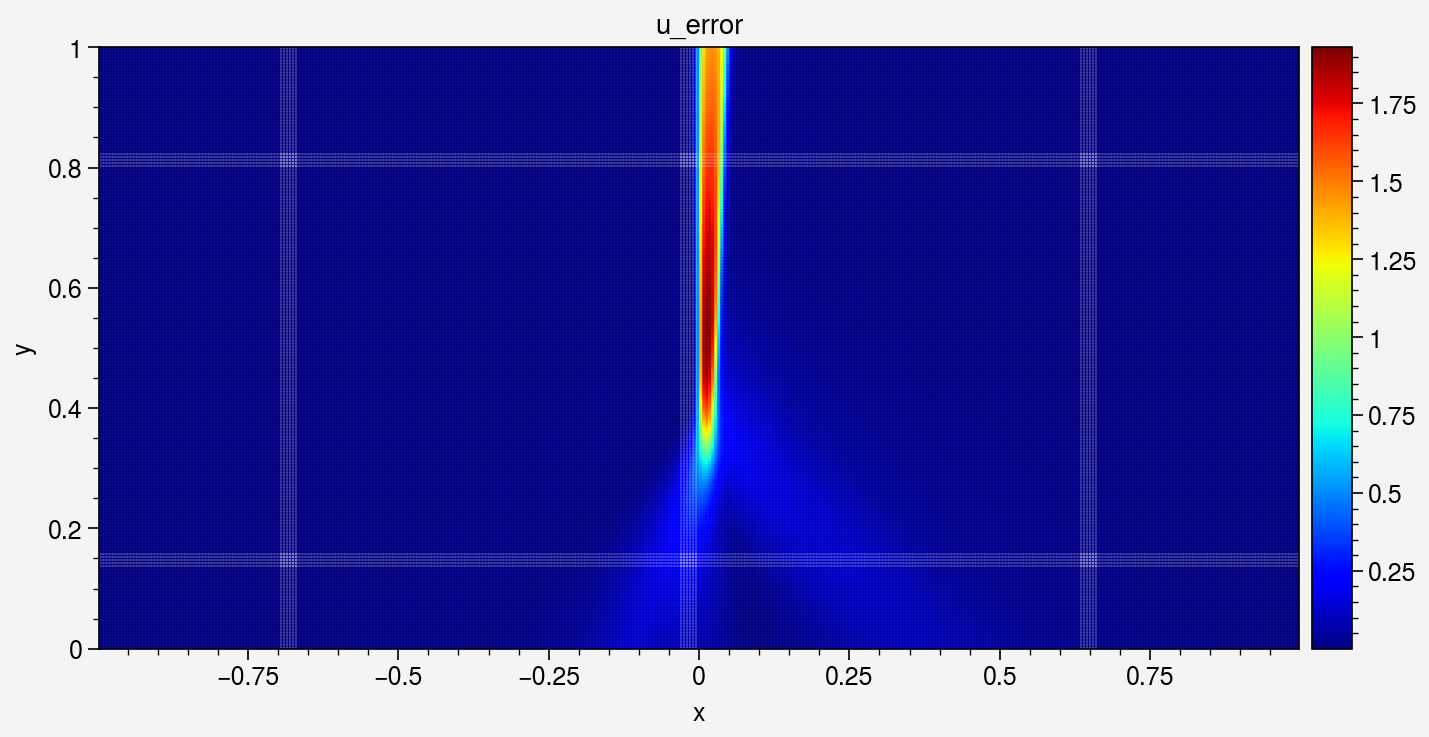

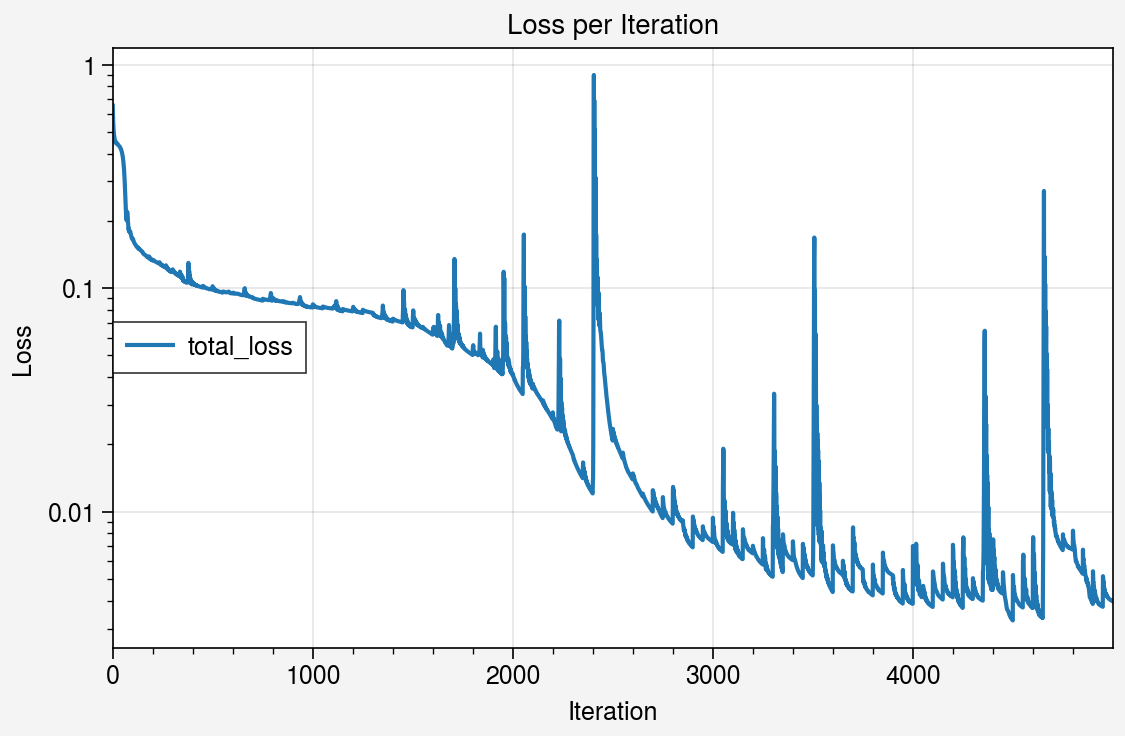

In [6]:
for method in sampling_methods:
    prediction = obj_dict[method]["prediction"] = domain_test.evaluate(obj_dict[method]["model"])
    prediction['u_sol'] = u
    prediction['u_error'] = np.abs(prediction['u']-prediction['u_sol'])
    obj_dict[method]['L2'] = np.sqrt(np.sum(prediction['u_error']**2)/np.sum(prediction['u_sol']**2))
    obj_dict[method]['L1'] = np.sum(prediction['u_error'])/np.sum(np.abs(prediction['u_sol']))

    print('L2 error for method', method, ':', obj_dict[method]['L2'])
    print('L1 error for method', method, ':', obj_dict[method]['L1'])
    prediction.plot_color('u', cmap = 'jet', s=0.5).savefig(f'u_field_{method}.png');
    prediction.plot_color('u_error', cmap = 'jet', s=0.5).savefig(f'u_field_{method}_error.png');
    prediction.plot_loss_curve(keys=['total_loss']).savefig(f'loss_curve_{method}.png');

### 4.2 Visualize u at y = 0.75

In [7]:
# line = df.geometry.line_horizontal(y=0.75, range_x=[-1, 1])
# prediction = line.evaluate(model1)
# prediction.sampling_line(500)
# _ = prediction.plot(y_axis = 'u')

In [8]:
# pred.plot_loss_curve(keys=['total_loss'])